In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [11]:
data = pd.read_csv(
    "Housing.csv"
    #header=None,
   # names=["Area", "Bedrooms", "Floors", "Age", "Price"]
)

data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [12]:
data = pd.get_dummies(
    data,
    drop_first=True,
    dtype=int
)

In [13]:
data.head()
data.info()
print("Dataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nSummary Statistics:")
display(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    int64
 7   guestroom_yes                    545 non-null    int64
 8   basement_yes                     545 non-null    int64
 9   hotwaterheating_yes              545 non-null    int64
 10  airconditioning_yes              545 non-null    int64
 11  prefarea_yes                     545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578,0.858716,0.177982,0.350459,0.045872,0.315596,0.234862,0.416514,0.326606
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586,0.348635,0.382849,0.477552,0.209399,0.465180,0.424302,0.493434,0.469402
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Missing Values:
price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
parking                            0
mainroad_yes                       0
guestroom_yes                      0
basement_yes                       0
hotwaterheating_yes                0
airconditioning_yes                0
prefarea_yes                       0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

Duplicate rows:
0


In [14]:
for col in data.columns:
    if data[col].isnull().sum() > 0:

        if data[col].dtype != "object":
            data[col].fillna(data[col].median(), inplace=True)

        else:
            data[col].fillna(data[col].mode()[0], inplace=True)

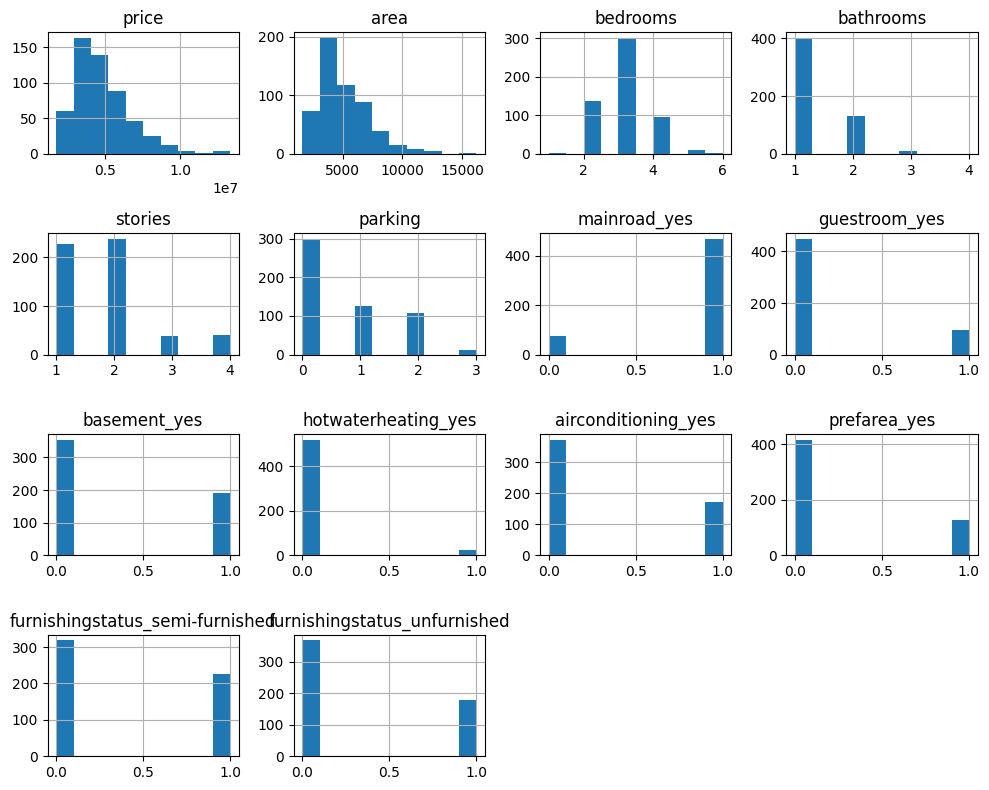

In [19]:
###exploratory data analysis
data.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [16]:
##getting features
target = "price"
features = data.columns.drop(target)

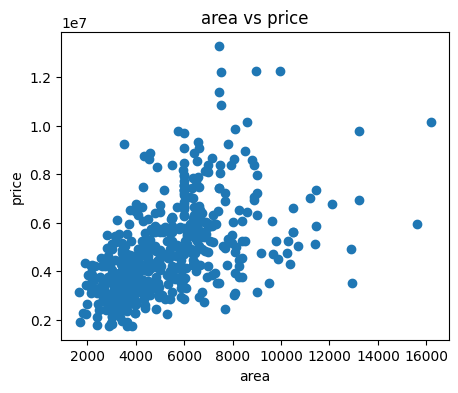

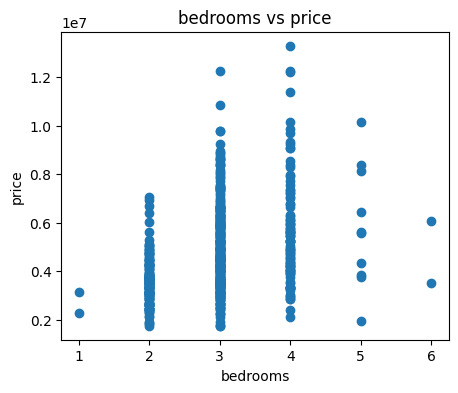

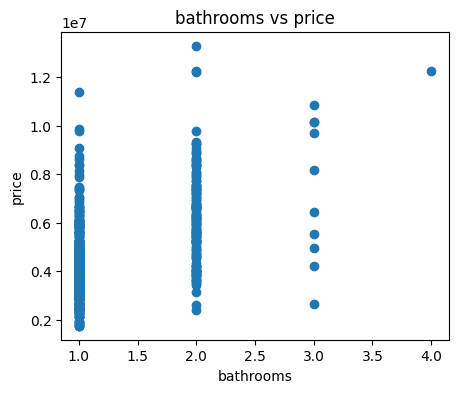

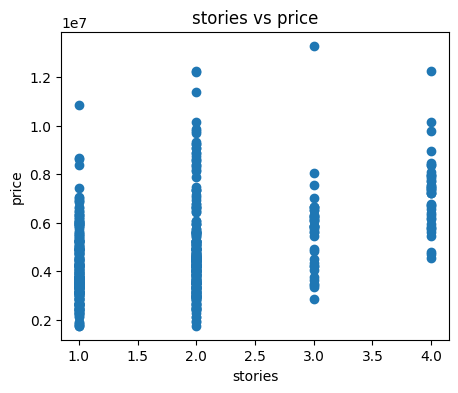

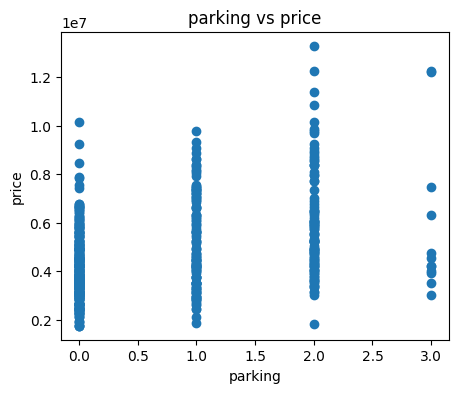

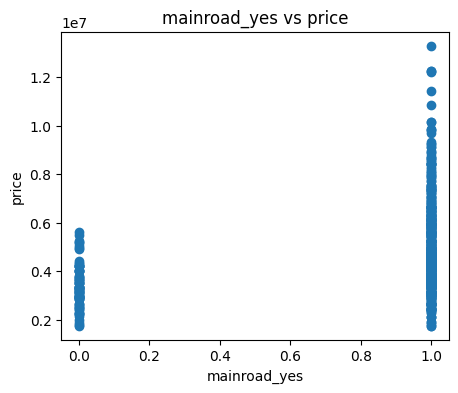

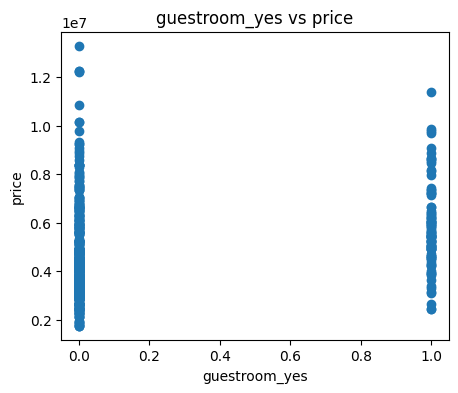

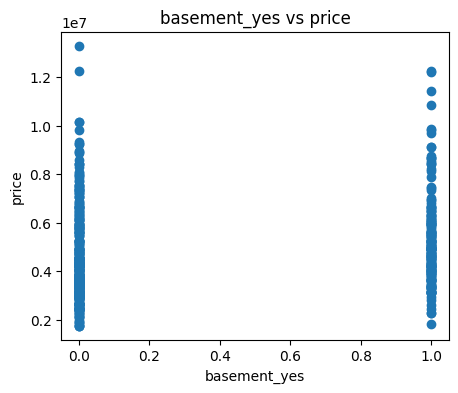

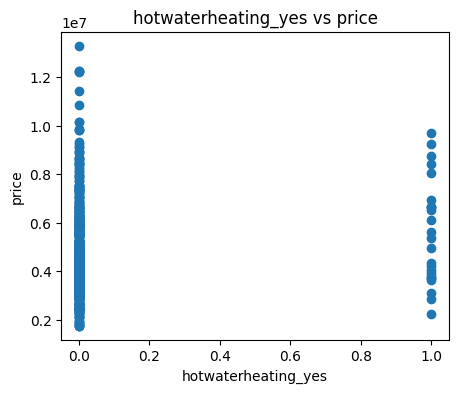

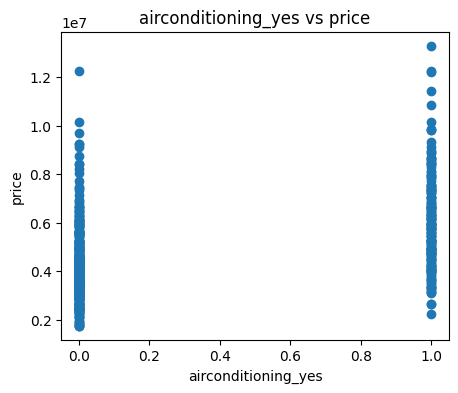

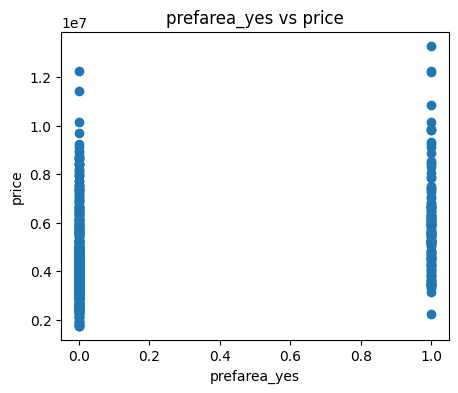

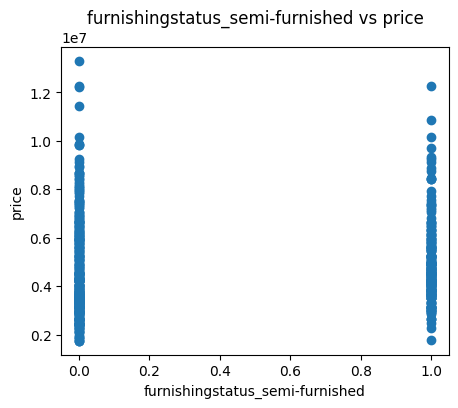

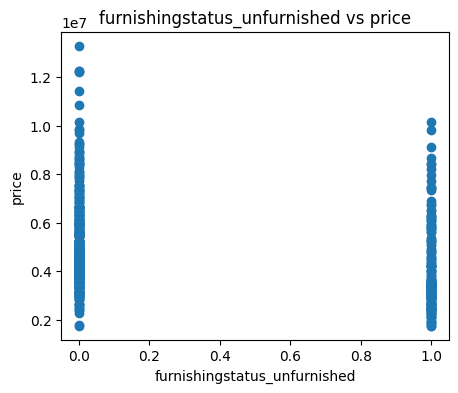

In [17]:
for feature in features:

    plt.figure(figsize=(5,4))

    plt.scatter(data[feature], data[target])

    plt.xlabel(feature)
    plt.ylabel(target)

    plt.title(f"{feature} vs {target}")

    plt.show()

In [18]:
##creating X and y for input variables and output
X = data[features]
y = data[target]
print("Features X:")
display(X.head())
print("\ny:")
display(y.head())

Features X:


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0



y:


,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


# Step 6: Split the Dataset

The dataset is divided into three parts:

- **Training Set**: Used to train the models.
- **Validation (CV) Set**: Used to compare different models and choose the best one.
- **Testing Set**: Used only once at the end to evaluate the final selected model.

In [20]:
# 70% training set, 15% cv set and 15% test set
## splitting training set
X_train, X_, y_train, y_ = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)  ### X_ and y_ are temporary variables

## now splitting CV and test set
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.5, random_state=42)

del X_
del y_

> ### Why do we use `fit_transform()` for the training set but only `transform()` for the validation and test sets?
>
> `StandardScaler` computes the **mean** and **standard deviation** of the data to standardize the features.
>
> - **Training Set:** We use `fit_transform()` because the scaler needs to **learn** (fit) the mean and standard deviation from the training data and then apply the transformation.
> - **Validation & Test Sets:** We use only `transform()` because these datasets must be treated as **unseen data**. They should be scaled using the **same mean and standard deviation learned from the training set**.
>
> Using `fit()` on the validation or test set would allow information from those datasets to influence the model, leading to **data leakage** and an unrealistic evaluation of model performance.

In [21]:
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the validation and testing data
X_cv_scaled = scaler.transform(X_cv)
X_test_scaled = scaler.transform(X_test)

In [22]:
print("Training Shape:", X_train_scaled.shape)
print("Validation Shape:", X_cv_scaled.shape)
print("Testing Shape:", X_test_scaled.shape)

Training Shape: (381, 13)
Validation Shape: (82, 13)
Testing Shape: (82, 13)


### Multiple Linear Regression

This is called multiple linear regression because there are multiple input variables.

In [23]:
# Create a Linear Regression model
linear_model = LinearRegression()

In [24]:
# Train the model using the scaled training data
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [25]:
# Generate predictions for the training and validation sets
y_train_pred_linear = linear_model.predict(X_train_scaled)
y_cv_pred_linear = linear_model.predict(X_cv_scaled)
y_test_pred_linear = linear_model.predict(X_test_scaled)

# Evaluate the Multiple Linear Regression Model

### Evaluation Metrics

- **MAE (Mean Absolute Error):** Average difference between the actual and predicted values. Lower is better.
- **MSE (Mean Squared Error):** Average of the squared prediction errors. Large errors have a much bigger effect than small errors.
- **RMSE (Root Mean Squared Error):** Square root of MSE. It is in the same units as the target variable, making it easier to understand.
- **R² Score (Coefficient of Determination):** Measures how well the model explains the variation in the target variable. A value closer to **1** indicates better performance.

In [26]:
# Calculate evaluation metrics for the training set
train_mae_linear = mean_absolute_error(y_train, y_train_pred_linear)
train_mse_linear = mean_squared_error(y_train, y_train_pred_linear)
train_rmse_linear = train_mse_linear ** 0.5
train_r2_linear = r2_score(y_train, y_train_pred_linear)

In [27]:
# Calculate evaluation metrics for the validation set
cv_mae_linear = mean_absolute_error(y_cv, y_cv_pred_linear)
cv_mse_linear = mean_squared_error(y_cv, y_cv_pred_linear)
cv_rmse_linear = cv_mse_linear ** 0.5
cv_r2_linear = r2_score(y_cv, y_cv_pred_linear)

In [28]:
# Calculate evaluation metrics for the test set
test_mae_linear = mean_absolute_error(y_test, y_test_pred_linear)
test_mse_linear = mean_squared_error(y_test, y_test_pred_linear)
test_rmse_linear = test_mse_linear ** 0.5
test_r2_linear = r2_score(y_test, y_test_pred_linear)

In [29]:
print("Training Set Performance")
print(f"MAE  : {train_mae_linear:.2f}")
print(f"MSE  : {train_mse_linear:.2f}")
print(f"RMSE : {train_rmse_linear:.2f}")
print(f"R²   : {train_r2_linear:.4f}")

print("\nValidation Set Performance")
print(f"MAE  : {cv_mae_linear:.2f}")
print(f"MSE  : {cv_mse_linear:.2f}")
print(f"RMSE : {cv_rmse_linear:.2f}")
print(f"R²   : {cv_r2_linear:.4f}")

print("\nTest Set Performance")
print(f"MAE  : {test_mae_linear:.2f}")
print(f"MSE  : {test_mse_linear:.2f}")
print(f"RMSE : {test_rmse_linear:.2f}")
print(f"R²   : {test_r2_linear:.4f}")

Training Set Performance
MAE  : 720245.20
MSE  : 963835379828.36
RMSE : 981751.18
R²   : 0.6932

Validation Set Performance
MAE  : 996133.44
MSE  : 1787515483846.20
RMSE : 1336979.99
R²   : 0.5862

Test Set Performance
MAE  : 844652.44
MSE  : 1258523455156.39
RMSE : 1121839.32
R²   : 0.7068


In [30]:
results = []

results.append({
    "Model": "Multiple Linear Regression",
    "Train RMSE": train_rmse_linear,
    "Train R²": train_r2_linear,
    "CV RMSE": cv_rmse_linear,
    "CV R²": cv_r2_linear,
    "Test RMSE": test_rmse_linear,
    "Test R²": test_r2_linear
})

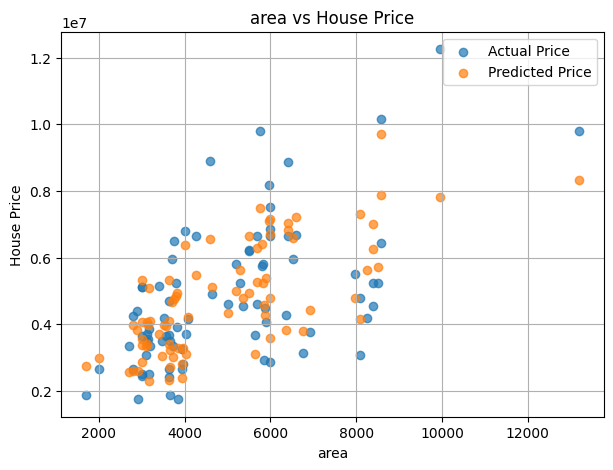

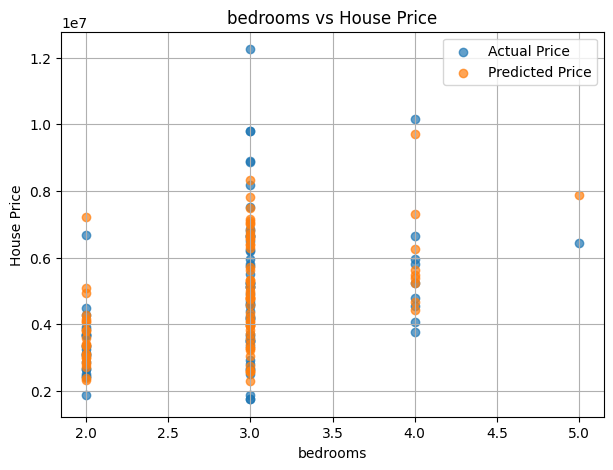

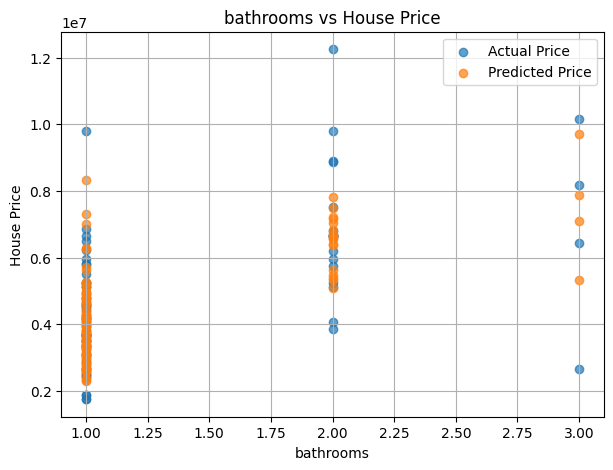

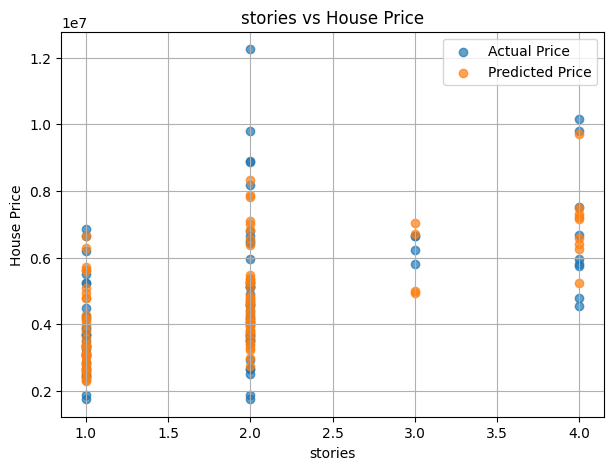

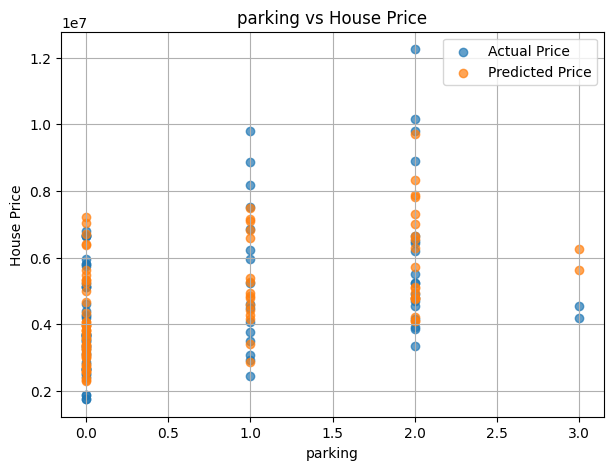

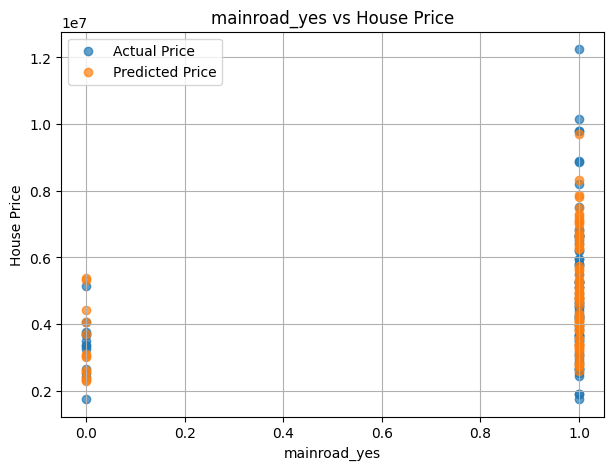

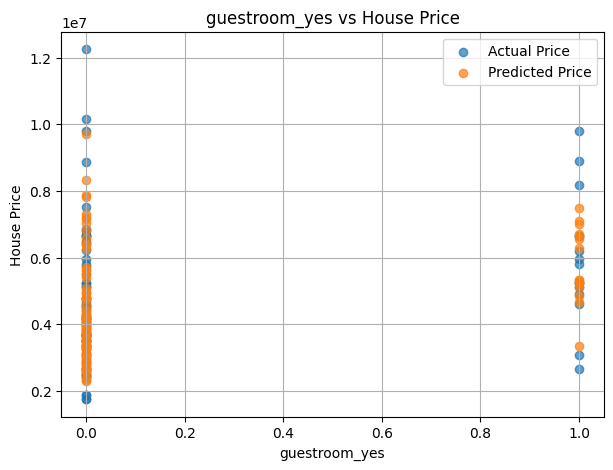

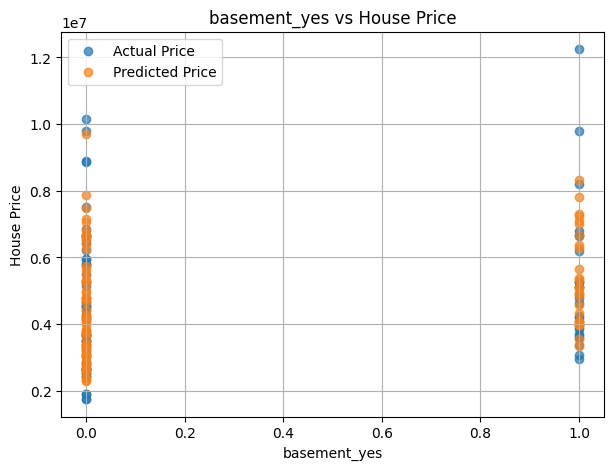

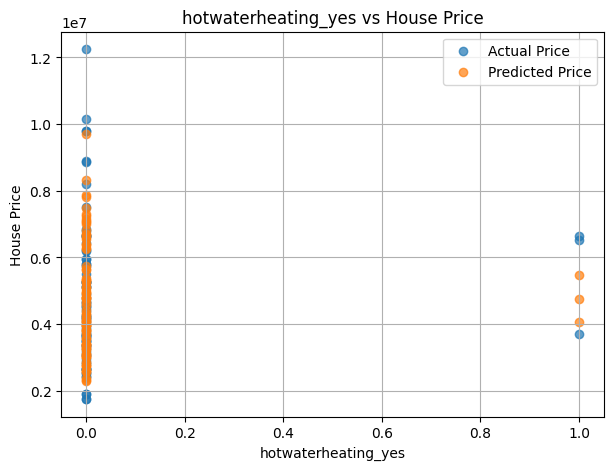

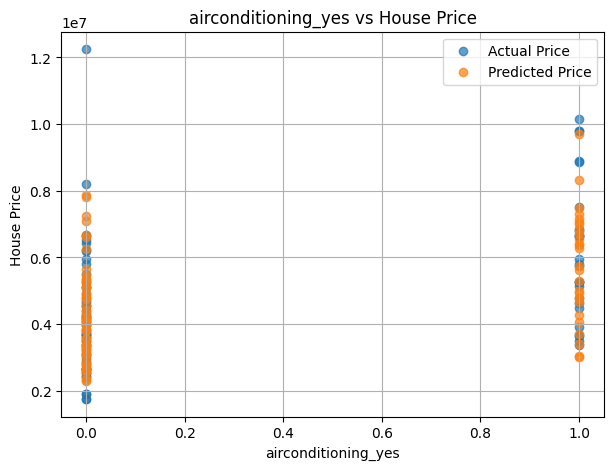

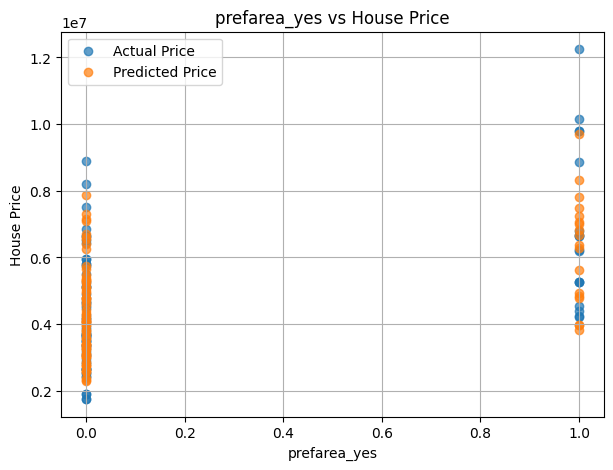

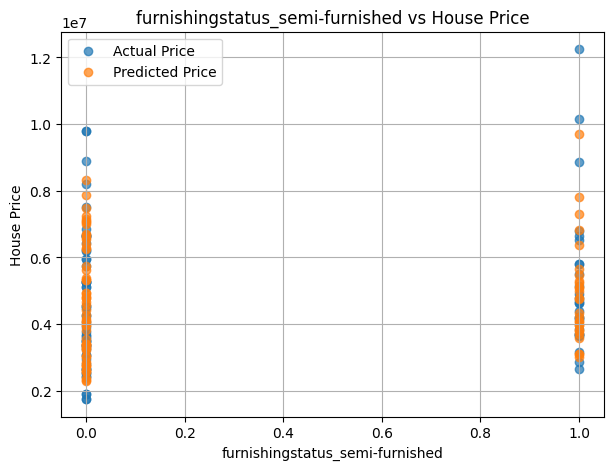

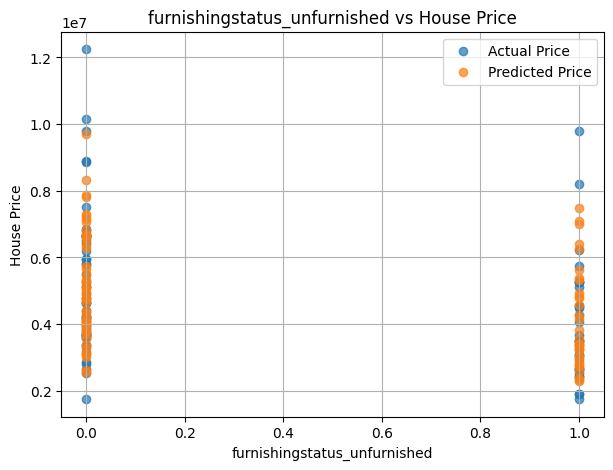

In [31]:
## plotting predicted y and actual y

for feature in features:

    plt.figure(figsize=(7,5))

    plt.scatter(
        X_test[feature],
        y_test,
        label="Actual Price",
        alpha=0.7
    )

    plt.scatter(
        X_test[feature],
        y_test_pred_linear,
        label="Predicted Price",
        alpha=0.7
    )

    plt.xlabel(feature)
    plt.ylabel("House Price")
    plt.title(f"{feature} vs House Price")

    plt.legend()
    plt.grid(True)

    plt.show()

### Polynomial Regression

Polynomial Regression creates additional polynomial features (such as squared terms and interaction terms) from the original input features. This allows the model to learn more complex relationships between the input features and the target variable.

In [56]:
degrees = range(1, 6)

In [57]:
# Store the results of Polynomial Regression models
poly_results = []

# Variables to store the best model
best_degree_poly = None
best_rmse_poly = float("inf")
best_model_poly = None
best_poly_poly = None
best_scaler_poly = None
best_train_rmse_poly = float("inf")
best_train_r2_poly = float("inf")
best_cv_rmse_poly = float("inf")
best_cv_r2_poly = float("inf")

In [58]:
# Compare Polynomial Regression models of different degrees
for degree in range(1, 6):

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    # Transform the training, validation and test sets
    X_train_poly = poly.fit_transform(X_train)
    X_cv_poly = poly.transform(X_cv)
    X_test_poly = poly.transform(X_test)

    # Scale the transformed features
    scaler = StandardScaler()

    X_train_poly_scaled = scaler.fit_transform(X_train_poly)
    X_cv_poly_scaled = scaler.transform(X_cv_poly)
    X_test_poly_scaled = scaler.transform(X_test_poly)
        # Create and train the model
    model = LinearRegression()
    model.fit(X_train_poly_scaled, y_train)

    # Generate predictions
    y_train_pred_poly = model.predict(X_train_poly_scaled)
    y_cv_pred_poly = model.predict(X_cv_poly_scaled)

    # Calculate evaluation metrics
    train_rmse_poly = mean_squared_error(y_train, y_train_pred_poly) ** 0.5
    cv_rmse_poly = mean_squared_error(y_cv, y_cv_pred_poly) ** 0.5

    train_r2_poly = r2_score(y_train, y_train_pred_poly)
    cv_r2_poly = r2_score(y_cv, y_cv_pred_poly)

    # Store the results
    poly_results.append({
        "Degree": degree,
        "Train RMSE": train_rmse_poly,
        "Train R²": train_r2_poly,
        "CV RMSE": cv_rmse_poly,
        "CV R²": cv_r2_poly
    })

    # Update the best model
    if cv_rmse_poly < best_rmse_poly:
        best_rmse_poly = cv_rmse_poly
        best_degree_poly = degree
        best_model_poly = model
        best_poly_poly = poly
        best_scaler_poly = scaler
        best_train_rmse_poly = train_rmse_poly
        best_train_r2_poly = train_r2_poly
        best_cv_rmse_poly = cv_rmse_poly
        best_cv_r2_poly = cv_r2_poly

In [59]:
comparison = pd.DataFrame(poly_results)

comparison

,Degree,Train RMSE,Train R²,CV RMSE,CV R²
0,1,981751.180202,0.693199,1.336980e+06,5.861884e-01
1,2,756132.273425,0.818009,1.391616e+06,5.516761e-01
2,3,152939.092717,0.992555,7.015015e+07,-1.138226e+03
3,4,92080.769712,0.997301,4.453568e+09,-4.591652e+06
4,5,87580.957589,0.997558,5.745293e+10,-7.641475e+08


In [60]:
print(f"Best Polynomial Degree : {best_degree_poly}")
print(f"Lowest Validation RMSE : {best_rmse_poly:.2f}")

print("\nBest Model:")
print(best_model_poly)

print("\nPolynomial Feature Generator:")
print(best_poly_poly)

print("\nFeature Scaler:")
print(best_scaler_poly)

Best Polynomial Degree : 1
Lowest Validation RMSE : 1336979.99

Best Model:
LinearRegression()

Polynomial Feature Generator:
PolynomialFeatures(degree=1, include_bias=False)

Feature Scaler:
StandardScaler()


In [61]:
# Transform the test set using the best polynomial transformer
X_test_poly_best = best_poly_poly.transform(X_test)

# Scale the transformed test set
X_test_best_poly_scaled = best_scaler_poly.transform(X_test_poly_best)

# Predict house prices
y_test_pred_poly_best = best_model_poly.predict(X_test_best_poly_scaled)

In [62]:
# Calculate evaluation metrics
test_mae_poly = mean_absolute_error(y_test, y_test_pred_poly_best)
test_mse_poly = mean_squared_error(y_test, y_test_pred_poly_best)
test_rmse_poly = test_mse_poly ** 0.5
test_r2_poly = r2_score(y_test, y_test_pred_poly_best)

print("Best Polynomial Regression Model Performance")

print(f"Polynomial Degree : {best_degree_poly}")

print(f"MAE  : {test_mae_poly:.2f}")
print(f"MSE  : {test_mse_poly:.2f}")
print(f"RMSE : {test_rmse_poly:.2f}")
print(f"R²   : {test_r2_poly:.4f}")

Best Polynomial Regression Model Performance
Polynomial Degree : 1
MAE  : 844652.44
MSE  : 1258523455156.39
RMSE : 1121839.32
R²   : 0.7068


In [63]:
results.append({
    "Model": f"Polynomial Regression (Degree {best_degree_poly})",
    "Train RMSE": best_train_rmse_poly,
    "Train R²": best_train_r2_poly,
    "CV RMSE": best_cv_rmse_poly,
    "CV R²": best_cv_r2_poly,
    "Test RMSE": test_rmse_poly,
    "Test R²": test_r2_poly
})

In [64]:
#print(y_test.head())

#print(y_test_pred_poly_best[:5])

In [65]:
#print(best_degree_poly)
#print(best_poly_poly.n_output_features_)

In [66]:
#len(y_test)
#len(y_test_pred_poly_best)

In [67]:
#print(X_train.shape)
#print(X_cv.shape)
#print(X_test.shape)

#print(y_train.shape)
#print(y_cv.shape)
#print(y_test.shape)

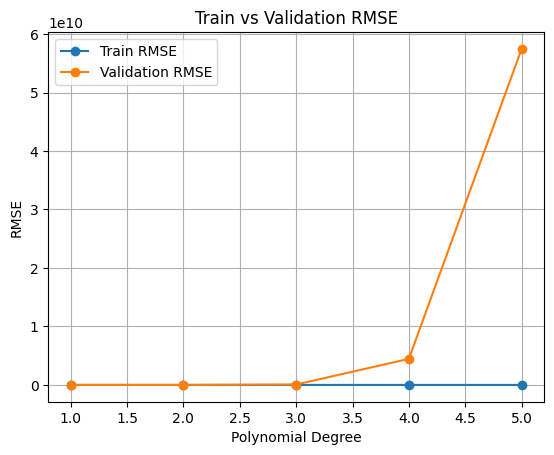

In [68]:
# plotting training vs cv
plt.plot(comparison["Degree"], comparison["Train RMSE"], marker="o", label="Train RMSE")
plt.plot(comparison["Degree"], comparison["CV RMSE"], marker="o", label="Validation RMSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Train vs Validation RMSE")

plt.legend()
plt.grid(True)

plt.show()

In [69]:
alphas = [0.01, 0.1, 1, 10, 100]

In [70]:
# Store the results of Ridge Regression models
ridge_results = []

# Variables to store the best Ridge model
best_degree_ridge = None
best_alpha_ridge = None
best_rmse_ridge = float("inf")

best_model_ridge = None
best_poly_ridge = None
best_scaler_ridge = None

best_train_rmse_ridge = float("inf")
best_train_r2_ridge = float("inf")
best_cv_rmse_ridge = float("inf")
best_cv_r2_ridge = float("inf")

In [71]:
for degree in range(1, 6):

    poly_ridge = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_ridge = poly_ridge.fit_transform(X_train)
    X_cv_ridge = poly_ridge.transform(X_cv)
    X_test_ridge = poly_ridge.transform(X_test)

    scaler_ridge = StandardScaler()

    X_train_ridge_scaled = scaler_ridge.fit_transform(X_train_ridge)
    X_cv_ridge_scaled = scaler_ridge.transform(X_cv_ridge)
    X_test_ridge_scaled = scaler_ridge.transform(X_test_ridge)

    for alpha in alphas:

        model_ridge = Ridge(alpha=alpha)

        model_ridge.fit(X_train_ridge_scaled, y_train)

        y_train_pred_ridge = model_ridge.predict(X_train_ridge_scaled)
        y_cv_pred_ridge = model_ridge.predict(X_cv_ridge_scaled)

        train_rmse_ridge = mean_squared_error(
            y_train,
            y_train_pred_ridge
        ) ** 0.5

        cv_rmse_ridge = mean_squared_error(
            y_cv,
            y_cv_pred_ridge
        ) ** 0.5

        train_r2_ridge = r2_score(
            y_train,
            y_train_pred_ridge
        )

        cv_r2_ridge = r2_score(
            y_cv,
            y_cv_pred_ridge
        )

              # Store the results
        ridge_results.append({
            "Degree": degree,
            "Alpha": alpha,
            "Train RMSE": train_rmse_ridge,
            "Train R²": train_r2_ridge,
            "CV RMSE": cv_rmse_ridge,
            "CV R²": cv_r2_ridge
        })

        # Update the best model
        if cv_rmse_ridge < best_rmse_ridge:
            best_rmse_ridge = cv_rmse_ridge
            best_degree_ridge = degree
            best_alpha_ridge = alpha

            best_model_ridge = model_ridge
            best_poly_ridge = poly_ridge
            best_scaler_ridge = scaler_ridge

            best_train_rmse_ridge = train_rmse_ridge
            best_train_r2_ridge = train_r2_ridge

            best_cv_rmse_ridge = cv_rmse_ridge
            best_cv_r2_ridge = cv_r2_ridge

In [72]:
ridge_comparison = pd.DataFrame(ridge_results)

ridge_comparison

,Degree,Alpha,Train RMSE,Train R²,CV RMSE,CV R²
0,1,0.01,981751.180466,0.693199,1.336978e+06,0.586190
1,1,0.10,981751.206538,0.693199,1.336961e+06,0.586200
2,1,1.00,981753.798411,0.693197,1.336796e+06,0.586302
3,1,10.00,981998.639608,0.693044,1.335430e+06,0.587147
4,1,100.00,997916.553438,0.683012,1.340372e+06,0.584086
5,2,0.01,756132.614113,0.818009,1.390899e+06,0.552138
6,2,0.10,756164.290074,0.817994,1.384790e+06,0.556063
7,2,1.00,758127.003633,0.817048,1.345442e+06,0.580933
8,2,10.00,786460.175409,0.803117,1.289487e+06,0.615065
9,2,100.00,858200.638394,0.765560,1.283450e+06,0.618662


In [73]:
print(f"Best Polynomial Degree : {best_degree_ridge}")
print(f"Best Alpha (λ)         : {best_alpha_ridge}")
print(f"Lowest Validation RMSE : {best_rmse_ridge:.2f}")

print("\nBest Model:")
print(best_model_ridge)

print("\nPolynomial Feature Generator:")
print(best_poly_ridge)

print("\nFeature Scaler:")
print(best_scaler_ridge)

Best Polynomial Degree : 2
Best Alpha (λ)         : 100
Lowest Validation RMSE : 1283449.73

Best Model:
Ridge(alpha=100)

Polynomial Feature Generator:
PolynomialFeatures(include_bias=False)

Feature Scaler:
StandardScaler()


In [74]:
X_test_ridge_best = best_poly_ridge.transform(X_test)

X_test_ridge_best_scaled = best_scaler_ridge.transform(X_test_ridge_best)

y_test_pred_ridge_best = best_model_ridge.predict(X_test_ridge_best_scaled)

In [75]:
# Calculate evaluation metrics
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge_best)
test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge_best)
test_rmse_ridge = test_mse_ridge ** 0.5
test_r2_ridge = r2_score(y_test, y_test_pred_ridge_best)

In [76]:
print("Best Ridge Regression Model Performance")

print(f"Polynomial Degree : {best_degree_ridge}")
print(f"Alpha (λ)         : {best_alpha_ridge}")

print(f"MAE  : {test_mae_ridge:.2f}")
print(f"MSE  : {test_mse_ridge:.2f}")
print(f"RMSE : {test_rmse_ridge:.2f}")
print(f"R²   : {test_r2_ridge:.4f}")

Best Ridge Regression Model Performance
Polynomial Degree : 2
Alpha (λ)         : 100
MAE  : 847913.74
MSE  : 1259208530091.64
RMSE : 1122144.61
R²   : 0.7067


In [77]:
results.append({
    "Model": f"Ridge Regression (Degree {best_degree_ridge}, λ={best_alpha_ridge})",

    "Train RMSE": best_train_rmse_ridge,
    "Train R²": best_train_r2_ridge,

    "CV RMSE": best_cv_rmse_ridge,
    "CV R²": best_cv_r2_ridge,

    "Test RMSE": test_rmse_ridge,
    "Test R²": test_r2_ridge
})

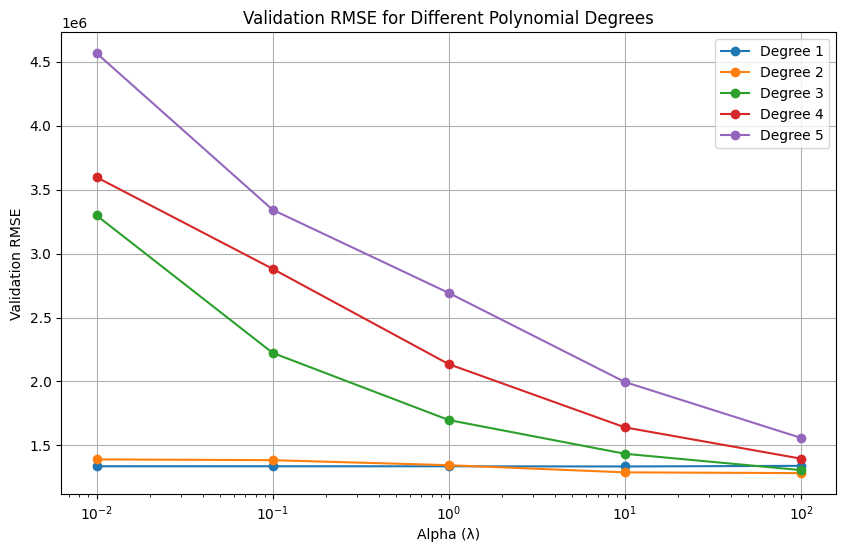

In [78]:
plt.figure(figsize=(10, 6))

for degree in range(1, 6):

    degree_data = ridge_comparison[
        ridge_comparison["Degree"] == degree
    ]

    plt.plot(
        degree_data["Alpha"],
        degree_data["CV RMSE"],
        marker="o",
        label=f"Degree {degree}"
    )

plt.xscale("log")

plt.xlabel("Alpha (λ)")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE for Different Polynomial Degrees")

plt.legend()

plt.grid(True)

plt.show()

In [79]:
#input
#area = float(input("Enter the house area (sq ft): "))
#bedrooms = float(input("Enter the number of bedrooms: "))
#floors = float(input("Enter the number of floors: "))
#age = float(input("Enter the house age (years): "))

In [80]:
#new_house = pd.DataFrame({
 #   "Area": [area],
#    "Bedrooms": [bedrooms],
#    "Floors": [floors],
#    "Age": [age]
#})

In [81]:
#X.describe()

In [82]:
#y.describe()

In [83]:
#similar_houses = data[
 #  (data["Floors"] == 2)
#]

#similar_houses

In [84]:
#data.corr(numeric_only=True)

### Decision Tree Regression

Decision Tree Regression is a non-linear machine learning algorithm that predicts values by splitting the data into smaller groups based on feature values. It can capture complex relationships without requiring feature scaling or polynomial features.

In [85]:
# Store the results of Decision Tree models
tree_results = []

# Variables to store the best model
best_depth_tree = None
best_rmse_tree = float("inf")

best_model_tree = None

In [86]:
depths = range(1, 7)

min_samples = [2, 5, 10, 15]

In [90]:
# Compare Decision Tree models with different hyperparameters
for depth in depths:

    for min_sample in min_samples:

        # Create the model
        model_tree = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_split=min_sample,
            random_state=42
        )

        # Train the model
        model_tree.fit(X_train, y_train)

        # Generate predictions
        y_train_pred_tree = model_tree.predict(X_train)
        y_cv_pred_tree = model_tree.predict(X_cv)

        # Calculate evaluation metrics
        train_rmse_tree = mean_squared_error(
            y_train,
            y_train_pred_tree
        ) ** 0.5

        cv_rmse_tree = mean_squared_error(
            y_cv,
            y_cv_pred_tree
        ) ** 0.5

        train_r2_tree = r2_score(
            y_train,
            y_train_pred_tree
        )

        cv_r2_tree = r2_score(
            y_cv,
            y_cv_pred_tree
        )

        # Store the results
        tree_results.append({
            "Max Depth": depth,
            "Min Samples Split": min_sample,
            "Train RMSE": train_rmse_tree,
            "Train R²": train_r2_tree,
            "CV RMSE": cv_rmse_tree,
            "CV R²": cv_r2_tree
        })

        # Update the best model
        if cv_rmse_tree < best_rmse_tree:

            best_rmse_tree = cv_rmse_tree
            best_depth_tree = depth
            best_min_samples_tree = min_sample

            best_model_tree = model_tree

            best_train_rmse_tree = train_rmse_tree
            best_train_r2_tree = train_r2_tree

            best_cv_rmse_tree = cv_rmse_tree
            best_cv_r2_tree = cv_r2_tree

In [91]:
tree_comparison = pd.DataFrame(tree_results)

tree_comparison

,Max Depth,Min Samples Split,Train RMSE,Train R²,CV RMSE,CV R²
0,1,2,1.416026e+06,0.361742,1.777572e+06,0.268512
1,1,5,1.416026e+06,0.361742,1.777572e+06,0.268512
2,1,10,1.416026e+06,0.361742,1.777572e+06,0.268512
3,1,15,1.416026e+06,0.361742,1.777572e+06,0.268512
4,2,2,1.261662e+06,0.493313,1.640880e+06,0.376686
5,2,5,1.261662e+06,0.493313,1.640880e+06,0.376686
6,2,10,1.261662e+06,0.493313,1.640880e+06,0.376686
7,2,15,1.261662e+06,0.493313,1.640880e+06,0.376686
8,3,2,1.115373e+06,0.604001,1.909428e+06,0.155967
9,3,5,1.115373e+06,0.604001,1.909428e+06,0.155967


In [92]:
print(f"Best Maximum Depth      : {best_depth_tree}")
print(f"Best Min Samples Split  : {best_min_samples_tree}")
print(f"Lowest Validation RMSE  : {best_rmse_tree:.2f}")

print("\nBest Model:")
print(best_model_tree)

Best Maximum Depth      : 2
Best Min Samples Split  : 2
Lowest Validation RMSE  : 1640880.38

Best Model:
DecisionTreeRegressor(max_depth=2, random_state=42)


In [93]:
# Predict house prices
y_test_pred_tree = best_model_tree.predict(X_test)

In [94]:
test_mae_tree = mean_absolute_error(y_test, y_test_pred_tree)
test_mse_tree = mean_squared_error(y_test, y_test_pred_tree)
test_rmse_tree = test_mse_tree ** 0.5
test_r2_tree = r2_score(y_test, y_test_pred_tree)

In [95]:
print("Best Decision Tree Model Performance")

print(f"Maximum Depth      : {best_depth_tree}")
print(f"Min Samples Split  : {best_min_samples_tree}")

print(f"MAE  : {test_mae_tree:.2f}")
print(f"MSE  : {test_mse_tree:.2f}")
print(f"RMSE : {test_rmse_tree:.2f}")
print(f"R²   : {test_r2_tree:.4f}")

Best Decision Tree Model Performance
Maximum Depth      : 2
Min Samples Split  : 2
MAE  : 1267428.06
MSE  : 2715915453498.47
RMSE : 1648003.47
R²   : 0.3674


In [96]:
results.append({
    "Model": f"Decision Tree (Depth {best_depth_tree}, Min Split {best_min_samples_tree})",

    "Train RMSE": best_train_rmse_tree,
    "Train R²": best_train_r2_tree,

    "CV RMSE": best_cv_rmse_tree,
    "CV R²": best_cv_r2_tree,

    "Test RMSE": test_rmse_tree,
    "Test R²": test_r2_tree
})

### Random Forest Regression

Random Forest Regression is an ensemble learning algorithm that combines the predictions of multiple decision trees to improve accuracy and reduce overfitting. The final prediction is obtained by averaging the predictions of all trees in the forest.

In [97]:
# Store the results of Random Forest models
forest_results = []

# Variables to store the best model
best_estimators_forest = None
best_depth_forest = None
best_min_samples_forest = None
best_rmse_forest = float("inf")

best_model_forest = None

In [98]:
n_estimators_list = [50, 100, 200]

depths = range(1, 7)

min_samples_list = [2, 5, 10, 15]

In [101]:
# Compare Random Forest models with different hyperparameters
for estimators in n_estimators_list:

    for depth in depths:

        for min_samples in min_samples_list:

            # Create the model
            model_forest = RandomForestRegressor(
                n_estimators=estimators,
                max_depth=depth,
                min_samples_split=min_samples,
                random_state=42
            )

            # Train the model
            model_forest.fit(X_train, y_train)

            # Generate predictions
            y_train_pred_forest = model_forest.predict(X_train)
            y_cv_pred_forest = model_forest.predict(X_cv)

            # Calculate evaluation metrics
            train_rmse_forest = mean_squared_error(
                y_train,
                y_train_pred_forest
            ) ** 0.5

            cv_rmse_forest = mean_squared_error(
                y_cv,
                y_cv_pred_forest
            ) ** 0.5

            train_r2_forest = r2_score(
                y_train,
                y_train_pred_forest
            )

            cv_r2_forest = r2_score(
                y_cv,
                y_cv_pred_forest
            )

            # Store the results
            forest_results.append({
                "Estimators": estimators,
                "Max Depth": depth,
                "Min Samples Split": min_samples,
                "Train RMSE": train_rmse_forest,
                "Train R²": train_r2_forest,
                "CV RMSE": cv_rmse_forest,
                "CV R²": cv_r2_forest
            })

            # Update the best model
            if cv_rmse_forest < best_rmse_forest:

                best_rmse_forest = cv_rmse_forest
                best_estimators_forest = estimators
                best_depth_forest = depth
                best_min_samples_forest = min_samples

                best_model_forest = model_forest

                best_train_rmse_forest = train_rmse_forest
                best_train_r2_forest = train_r2_forest

                best_cv_rmse_forest = cv_rmse_forest
                best_cv_r2_forest = cv_r2_forest

In [102]:
forest_comparison = pd.DataFrame(forest_results)

forest_comparison

,Estimators,Max Depth,Min Samples Split,Train RMSE,Train R²,CV RMSE,CV R²
0,50,1,2,1.407320e+06,0.369566,1.770512e+06,0.274311
1,50,1,5,1.407320e+06,0.369566,1.770512e+06,0.274311
2,50,1,10,1.407320e+06,0.369566,1.770512e+06,0.274311
3,50,1,15,1.407320e+06,0.369566,1.770512e+06,0.274311
4,50,2,2,1.185538e+06,0.552612,1.570753e+06,0.428826
...,...,...,...,...,...,...,...
139,200,5,15,8.545051e+05,0.767575,1.431555e+06,0.525573
140,200,6,2,6.516468e+05,0.864831,1.391766e+06,0.551580
141,200,6,5,6.959710e+05,0.845817,1.404268e+06,0.543487
142,200,6,10,7.613310e+05,0.815498,1.412780e+06,0.537936


In [103]:
print(f"Best Number of Estimators : {best_estimators_forest}")
print(f"Best Maximum Depth        : {best_depth_forest}")
print(f"Best Min Samples Split    : {best_min_samples_forest}")
print(f"Lowest Validation RMSE    : {best_rmse_forest:.2f}")

print("\nBest Model:")
print(best_model_forest)

Best Number of Estimators : 100
Best Maximum Depth        : 6
Best Min Samples Split    : 2
Lowest Validation RMSE    : 1380833.61

Best Model:
RandomForestRegressor(max_depth=6, random_state=42)


In [104]:
# Predict house prices
y_test_pred_forest = best_model_forest.predict(X_test)

In [105]:
test_mae_forest = mean_absolute_error(y_test, y_test_pred_forest)
test_mse_forest = mean_squared_error(y_test, y_test_pred_forest)
test_rmse_forest = test_mse_forest ** 0.5
test_r2_forest = r2_score(y_test, y_test_pred_forest)

In [106]:
print("Best Random Forest Model Performance")

print(f"Number of Estimators : {best_estimators_forest}")
print(f"Maximum Depth        : {best_depth_forest}")
print(f"Min Samples Split    : {best_min_samples_forest}")

print(f"MAE  : {test_mae_forest:.2f}")
print(f"MSE  : {test_mse_forest:.2f}")
print(f"RMSE : {test_rmse_forest:.2f}")
print(f"R²   : {test_r2_forest:.4f}")

Best Random Forest Model Performance
Number of Estimators : 100
Maximum Depth        : 6
Min Samples Split    : 2
MAE  : 983309.46
MSE  : 1836743999677.27
RMSE : 1355265.29
R²   : 0.5722


In [107]:
results.append({
    "Model": (
        f"Random Forest "
        f"(Trees {best_estimators_forest}, "
        f"Depth {best_depth_forest}, "
        f"Min Split {best_min_samples_forest})"
    ),

    "Train RMSE": best_train_rmse_forest,
    "Train R²": best_train_r2_forest,

    "CV RMSE": best_cv_rmse_forest,
    "CV R²": best_cv_r2_forest,

    "Test RMSE": test_rmse_forest,
    "Test R²": test_r2_forest
})

In [108]:
final_comparison = pd.DataFrame(results)

final_comparison

,Model,Train RMSE,Train R²,CV RMSE,CV R²,Test RMSE,Test R²
0,Multiple Linear Regression,9.817512e+05,0.693199,1.336980e+06,0.586188,1.121839e+06,0.706844
1,Polynomial Regression (Degree 1),9.817512e+05,0.693199,1.336980e+06,0.586188,1.121839e+06,0.706844
2,Polynomial Regression (Degree 1),9.817512e+05,0.693199,1.336980e+06,0.586188,1.121839e+06,0.706844
3,"Ridge Regression (Degree 2, λ=100)",8.582006e+05,0.765560,1.283450e+06,0.618662,1.122145e+06,0.706685
4,"Decision Tree (Depth 2, Min Split 2)",1.261662e+06,0.493313,1.640880e+06,0.376686,1.648003e+06,0.367365
5,"Random Forest (Trees 100, Depth 6, Min Split 2)",6.533215e+05,0.864135,1.380834e+06,0.558597,1.355265e+06,0.572156


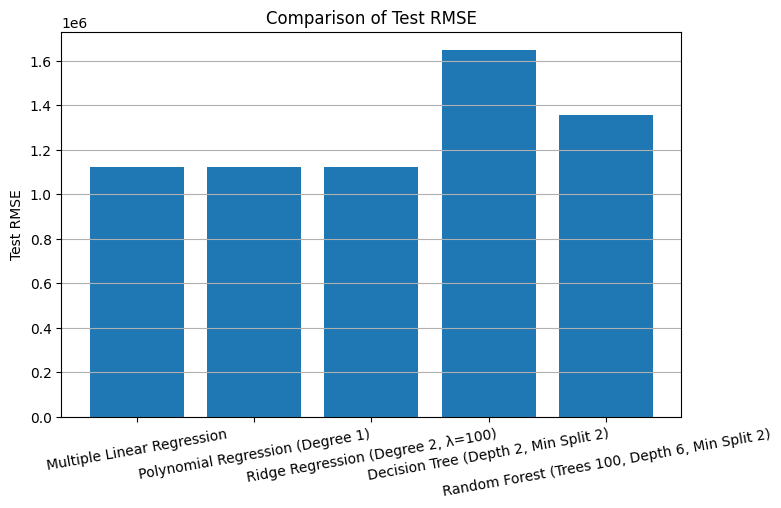

In [109]:
plt.figure(figsize=(8,5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Test RMSE"]
)

plt.ylabel("Test RMSE")
plt.title("Comparison of Test RMSE")

plt.xticks(rotation=10)

plt.grid(axis="y")

plt.show()

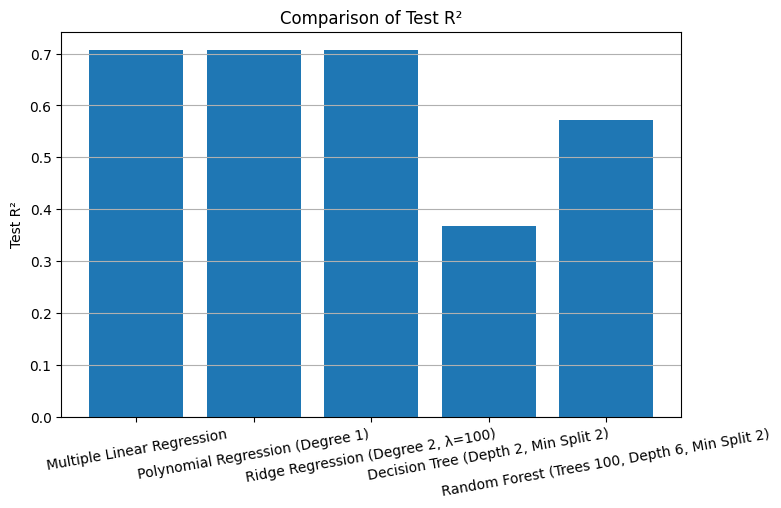

In [110]:
plt.figure(figsize=(8,5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Test R²"]
)

plt.ylabel("Test R²")
plt.title("Comparison of Test R²")

plt.xticks(rotation=10)

plt.grid(axis="y")

plt.show()

In [111]:
best_model = final_comparison.loc[
    final_comparison["Test RMSE"].idxmin()
]

print("Best Model")

print(f"Model      : {best_model['Model']}")
print(f"Test RMSE  : {best_model['Test RMSE']:.2f}")
print(f"Test R²    : {best_model['Test R²']:.4f}")

Best Model
Model      : Multiple Linear Regression
Test RMSE  : 1121839.32
Test R²    : 0.7068


### Prediction

The trained model can estimate the price of a new house by taking the house features as input.

In [146]:
#input
new_data = {}

for feature in X.columns:
    value = float(input(f"Enter {feature}: "))
    new_data[feature] = [value]

new_house = pd.DataFrame(new_data)

KeyboardInterrupt: Interrupted by user

In [ ]:
if "Multiple Linear Regression" in best_model["Model"]:

    new_house_scaled = scaler.transform(new_house)
    predicted_price = linear_model.predict(new_house_scaled)

elif "Polynomial Regression" in best_model["Model"]:

    new_house_poly = best_poly_poly.transform(new_house)
    new_house_scaled = best_scaler_poly.transform(new_house_poly)
    predicted_price = best_model_poly.predict(new_house_scaled)

elif "Ridge Regression" in best_model["Model"]:

    new_house_poly = best_poly_ridge.transform(new_house)
    new_house_scaled = best_scaler_ridge.transform(new_house_poly)
    predicted_price = best_model_ridge.predict(new_house_scaled)

elif "Decision Tree" in best_model["Model"]:

    predicted_price = best_model_tree.predict(new_house)

elif "Random Forest" in best_model["Model"]:

    predicted_price = best_model_forest.predict(new_house)

print(f"\nEstimated House Price: {predicted_price[0]:.2f}")